# Обзор данных (мужские матчи)

Ниже три блока в одном порядке: **турниры** → **игроки** → **матчи**. В каждом: пример строк, таблица полей, затем пропуски, распределения и явные аномалии. В конце краткое резюме.


In [78]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt

DATA = "../../data/raw"

matches = pd.read_csv(f"{DATA}/men/matches.csv", parse_dates=["played_at"])
players = pd.read_csv(f"{DATA}/men/players.csv")
tournaments = pd.read_csv(f"{DATA}/tournaments.csv", parse_dates=["start_date", "end_date"])

matches["year"] = matches["played_at"].dt.year
matches["year_month"] = matches["played_at"].dt.to_period("M")

print(f"Матчей: {len(matches)}")
print(f"Игроков: {len(players)}")
print(f"Турниров: {len(tournaments)}")


Матчей: 2616
Игроков: 405
Турниров: 91


## 1. Турниры (`tournaments`)


In [79]:
tournaments.head()


,tournament_id,name,location,country,level,status,start_date,end_date
0,7,Ooredoo Qatar Major Premier Padel,Doha,QA,major,finished,2023-02-26,2023-03-05
1,41,Bnl Italy Major Premier Padel,Roma,IT,major,finished,2023-07-08,2023-07-16
2,48,Madrid Premier Padel P1,Madrid,ES,p1,finished,2023-07-15,2023-07-23
3,54,Mendoza Premier Padel P1,Mendoza,AR,p1,finished,2023-07-29,2023-08-06
4,65,Paris Major Premier Padel,Paris,FR,major,finished,2023-09-03,2023-09-10


### Поля `tournaments`

| Поле | Тип | Описание |
|---|---|---|
| `tournament_id` | int | Уникальный идентификатор турнира |
| `name` | str | Название турнира |
| `location` | str | Город проведения |
| `country` | str | Страна (ISO 2-буквенный код) |
| `level` | str | Уровень турнира: `major`, `p1`, `p2`, `fip_platinum`, `finals` |
| `status` | str | Статус: `finished` / `ongoing` |
| `start_date` | datetime | Дата начала |
| `end_date` | datetime | Дата окончания |


In [81]:
print("Размер:", tournaments.shape)
print("\nТипы:")
print(tournaments.dtypes)
print("\nПропуски по столбцам:")
na = tournaments.isnull().sum()
print(na[na > 0] if na.max() > 0 else "  (нет)")
print("\nУникальные level:", tournaments["level"].dropna().unique().tolist())
print("Уникальные status:", tournaments["status"].dropna().unique().tolist())
print("\nСтраны (топ-10):")
print(tournaments["country"].value_counts().head(10))
bad = (tournaments["start_date"] > tournaments["end_date"]).sum()
print(f"\nСтрок с start_date > end_date: {bad}")
if bad:
    print(tournaments.loc[tournaments["start_date"] > tournaments["end_date"], ["tournament_id", "name", "start_date", "end_date"]])


Размер: (91, 8)

Типы:
tournament_id             int64
name                     object
location                 object
country                  object
level                    object
status                   object
start_date       datetime64[ns]
end_date         datetime64[ns]
dtype: object

Пропуски по столбцам:
  (нет)

Уникальные level: ['major', 'p1', 'fip_platinum', 'p2', 'finals']
Уникальные status: ['finished', 'pending']

Страны (топ-10):
country
ES    20
IT    11
MX    11
FR    10
AR     4
QA     3
AE     3
EG     3
NL     3
PY     3
Name: count, dtype: int64

Строк с start_date > end_date: 0


## 2. Игроки (`players`)


In [82]:
players.head()


,player_id,name,short_name,category,ranking,points,height,nationality,birthplace,birthdate,age,hand,side
0,1,Facundo Dominguez,Dominguez,men,65.0,1005.0,172.0,IT,Mar del Plata,1997-11-09,28.0,right,backhand
1,2,Denis Tomas Perino,Tomas,men,49.0,1184.0,174.0,IT,Córdoba,1996-01-08,30.0,left,drive
2,3,Juan Carlos Vargas Vera,Carlos,men,906.0,18.0,NaN,MX,NaN,1999-09-13,26.0,NaN,NaN
3,4,Sergio Jimenez Amozurrutia,Jimenez,men,589.0,41.0,NaN,MX,NaN,1988-04-17,37.0,NaN,NaN
4,5,Zé Alexandre Meireles,Alexandre,men,246.0,167.0,185.0,PT,Guimaraes,1999-11-30,26.0,NaN,backhand


### Поля `players`

| Поле | Тип | Описание |
|---|---|---|
| `player_id` | int | Уникальный идентификатор игрока |
| `name` | str | Полное имя |
| `short_name` | str | Короткое имя |
| `category` | str | Категория |
| `ranking` | float | Позиция в рейтинге |
| `points` | float | Рейтинговые очки |
| `height` | float | Рост (см) |
| `nationality` | str | Национальность (ISO) |
| `birthplace` | str | Место рождения |
| `birthdate` | str | Дата рождения |
| `age` | float | Возраст |
| `hand` | str | Рабочая рука (`right` / `left`) |
| `side` | str | Сторона (`drive` / `backhand`) |


Пропуски в players (столбцы с хотя бы одним NaN):
ranking         3
points          3
height         73
birthplace     62
birthdate       5
age             5
hand          269
side           70
dtype: int64


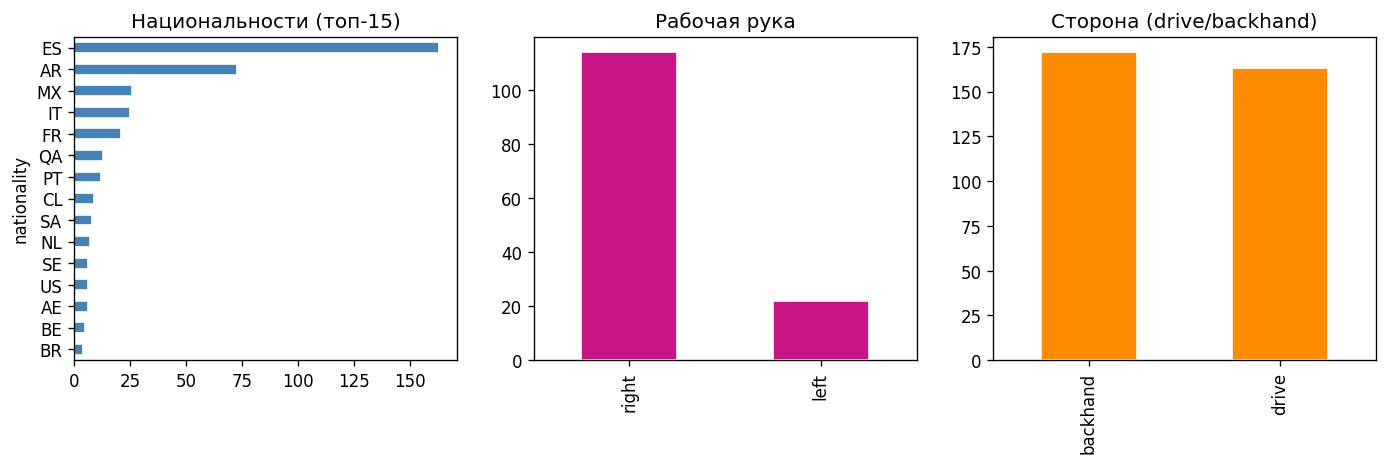

In [83]:
print("Пропуски в players (столбцы с хотя бы одним NaN):")
pn = players.isnull().sum()
pn = pn[pn > 0]
print(pn if len(pn) else "  (нет)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

players["nationality"].value_counts().head(15).plot.barh(
    ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Национальности (топ-15)")
axes[0].invert_yaxis()

players["hand"].value_counts().plot.bar(
    ax=axes[1], color="mediumvioletred", edgecolor="white"
)
axes[1].set_title("Рабочая рука")
axes[1].set_xlabel("")

players["side"].value_counts().plot.bar(
    ax=axes[2], color="darkorange", edgecolor="white"
)
axes[2].set_title("Сторона (drive/backhand)")
axes[2].set_xlabel("")

plt.show()


### Числовые поля: распределение и выбросы


In [84]:
num_cols = ["ranking", "points", "height", "age"]
for c in num_cols:
    s = pd.to_numeric(players[c], errors="coerce")
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = ((s < lo) | (s > hi)) & s.notna()
    print(f"{c}: min={s.min():.3g} max={s.max():.3g} | выбросов IQR: {out.sum()}")
print()
print(players[num_cols].describe())


ranking: min=1 max=2.98e+03 | выбросов IQR: 43
points: min=0 max=2.09e+04 | выбросов IQR: 43
height: min=160 max=201 | выбросов IQR: 4
age: min=17 max=50 | выбросов IQR: 6

           ranking        points      height        age
count   402.000000    402.000000  332.000000  400.00000
mean    562.781095    736.644279  180.695783   27.37750
std     788.776932   2117.858216    6.794407    6.58014
min       1.000000      0.000000  160.000000   17.00000
25%     101.250000     35.000000  176.000000   22.00000
50%     229.000000    186.000000  180.000000   27.00000
75%     639.000000    561.500000  185.000000   31.00000
max    2980.000000  20910.000000  201.000000   50.00000


## 3. Матчи (`matches`)


In [85]:
matches.head()


,match_id,tournament_id,player_id_1,player_id_2,player_id_3,player_id_4,category,name,round,round_name,...,court_order,status,score_json,winner,started_time,duration,pbp_json,stats_json,year,year_month
0,1306,7,235,236,107,267,men,Windahl/Solano - Mouriño/Mena,32,Round of 64,...,NaN,finished,"[{""team_1"":""7"",""team_2"":""5""},{""team_1"":""6"",""te...",team_1,NaN,NaN,"{""id"":1306,""self"":""/api/matches/1306/live"",""st...","{""id"":1306,""self"":""/api/matches/1306/stats"",""m...",2023,2023-02
1,1307,7,233,246,98,237,men,Luis/Luque - Semmler/Lijo,32,Round of 64,...,NaN,finished,"[{""team_1"":""3"",""team_2"":""6""},{""team_1"":""4"",""te...",team_2,NaN,NaN,"{""id"":1307,""self"":""/api/matches/1307/live"",""st...","{""id"":1307,""self"":""/api/matches/1307/stats"",""m...",2023,2023-02
2,1308,7,47,247,89,102,men,Rodriguez/German - Yanguas/Arroyo,32,Round of 64,...,NaN,finished,"[{""team_1"":""3"",""team_2"":""6""},{""team_1"":""3"",""te...",team_2,NaN,NaN,"{""id"":1308,""self"":""/api/matches/1308/live"",""st...","{""id"":1308,""self"":""/api/matches/1308/stats"",""m...",2023,2023-02
3,1309,7,68,76,248,249,men,Bergamini/Ruiz - Gomez/Martin,32,Round of 64,...,NaN,finished,"[{""team_1"":""3"",""team_2"":""6""},{""team_1"":""6"",""te...",team_1,NaN,NaN,"{""id"":1309,""self"":""/api/matches/1309/live"",""st...","{""id"":1309,""self"":""/api/matches/1309/stats"",""m...",2023,2023-02
4,1310,7,82,105,307,308,men,Guerrero/Moya - Abdulla/Alsaygh,32,Round of 64,...,NaN,finished,"[{""team_1"":""6"",""team_2"":""1""},{""team_1"":""6"",""te...",team_1,NaN,NaN,"{""id"":1310,""self"":""/api/matches/1310/live"",""st...","{""id"":1310,""self"":""/api/matches/1310/stats"",""m...",2023,2023-02


### Поля `matches`

| Поле | Тип | Описание |
|---|---|---|
| `match_id` | int | Уникальный идентификатор матча |
| `tournament_id` | int | Уникальный идентификатор турнира |
| `player_id_1`, `player_id_2` | int | Игроки команды 1 |
| `player_id_3`, `player_id_4` | int | Игроки команды 2 |
| `category` | str | Категория (в выборке только мужские матчи) |
| `name` | str | Текстовое название пары |
| `round` | int | Раунд турнира (1 = финал, 2 = полуфинал, …) |
| `round_name` | str | Текстовое название раунда |
| `index` | int | Порядковый номер матча в сетке |
| `played_at` | datetime | Дата матча |
| `schedule_label` | str | Метка в расписании |
| `court` | str | Название корта |
| `court_order` | float | Порядок матча на корте |
| `status` | str | Статус матча: `finished`, `retired`, `walkover`, `bye` |
| `score_json` | str (JSON) | Счёт по сетам |
| `winner` | str | Победитель: `team_1` / `team_2` |
| `started_time` | str | Время начала (как в API) |
| `duration` | str | Длительность (как в API) |
| `pbp_json` | str (JSON) | Point-by-point |
| `stats_json` | str (JSON) | Агрегированная статистика матча и сетов |


### `stats_json`


In [90]:
key_m = [
    "match_id", "tournament_id", "player_id_1", "player_id_2", "player_id_3", "player_id_4",
    "played_at", "status", "score_json", "winner", "stats_json", "pbp_json",
]
print("Пропуски в ключевых столбцах matches:")
nm = matches[key_m].isnull().sum()
shown = False
for col in nm.index:
    if nm[col] > 0:
        print(f"  {col}: {nm[col]} ({nm[col] / len(matches):.1%})")
        shown = True
if not shown:
    print("  (нет)")

has_stats_cell = matches["stats_json"].notna() & (matches["stats_json"].astype(str).str.strip() != "")


def _match_block_nonempty(val):
    if pd.isna(val) or str(val).strip() == "":
        return False
    try:
        d = json.loads(val)
        m = d.get("match")
        return bool(m)
    except (json.JSONDecodeError, TypeError):
        return False


inner = matches["stats_json"].apply(_match_block_nonempty)
print(f"Статистика на уровне матча заполнена: {inner.sum()} ({inner.mean():.1%})")


Пропуски в ключевых столбцах matches:
  score_json: 16 (0.6%)
  winner: 2 (0.1%)
Статистика на уровне матча заполнена: 2385 (91.2%)


In [102]:
sample_stats = json.loads(matches.loc[50, "stats_json"])

if "match" in sample_stats:
    print("\nСтатистики на уровне матча, пример:")
    for k, v in sample_stats["match"].items():
        print(f"  {k}: {v}")
    print()



Статистики на уровне матча, пример:
  total_points_won: {'team_1': '43%', 'team_2': '57%'}
  break_points_converted: {'team_1': '67%', 'team_2': '44%'}
  longest_streak: {'team_1': '4', 'team_2': '9'}
  aces: {'team_1': '0', 'team_2': '0'}
  double_faults: {'team_1': '0', 'team_2': '0'}
  won_on_1st_serve: {'team_1': '50%', 'team_2': '66%'}
  won_on_2nd_serve: {'team_1': '50%', 'team_2': '33%'}
  service_games: {'team_1': '9', 'team_2': '10'}
  won_on_1st_return: {'team_1': '34%', 'team_2': '50%'}
  won_on_2nd_return: {'team_1': '67%', 'team_2': '50%'}
  return_games: {'team_1': '10', 'team_2': '9'}
  total_won_on_serve: {'team_1': '50%', 'team_2': '64%'}
  total_won_on_return: {'team_1': '36%', 'team_2': '50%'}



In [104]:
set_availability = {"set_1": 0, "set_2": 0, "set_3": 0}
for s in matches.loc[:, "stats_json"]:
    d = json.loads(s)
    for k in set_availability:
        if k in d and d[k]:
            set_availability[k] += 1

print("Доступность посетовой статистики:")
for k, v in set_availability.items():
    print(f"  {k}: {v} матчей")

Доступность посетовой статистики:
  set_1: 2385 матчей
  set_2: 2373 матчей
  set_3: 655 матчей


### Период данных


Матчей по годам:
year
2023     364
2024    1068
2025    1009
2026     175
dtype: int64

Диапазон дат: 2023-02-28 — 2026-03-29


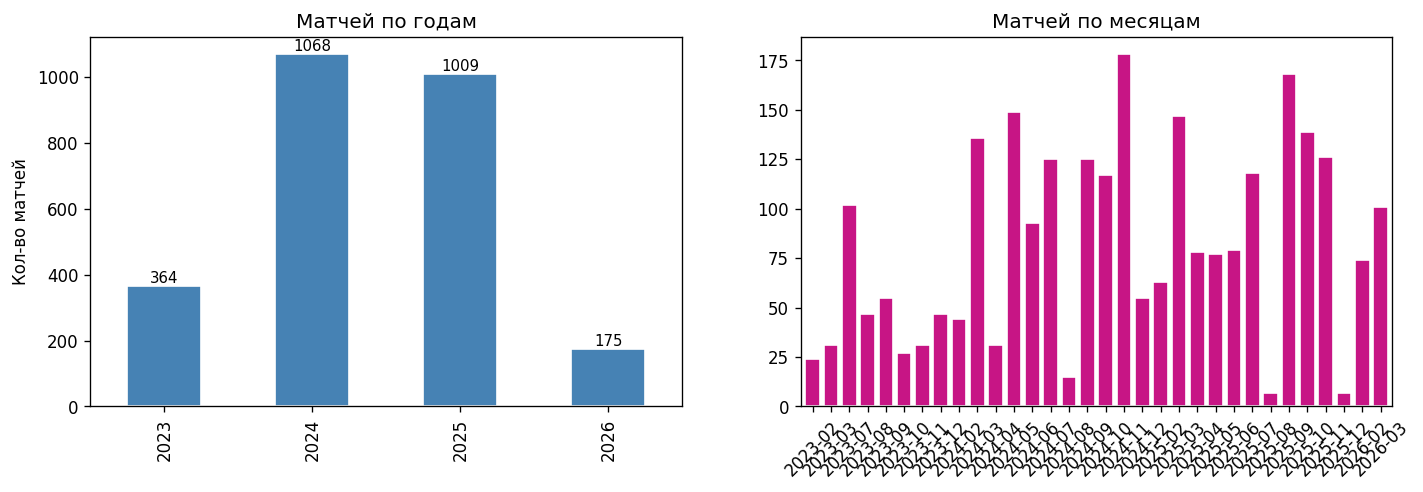

In [92]:
year_counts = matches.groupby("year").size()
print("Матчей по годам:")
print(year_counts)
print(f"\nДиапазон дат: {matches['played_at'].min().date()} — {matches['played_at'].max().date()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

year_counts.plot.bar(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Матчей по годам")
axes[0].set_ylabel("Кол-во матчей")
axes[0].set_xlabel("")
for i, v in enumerate(year_counts):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=9)

month_counts = matches.groupby("year_month").size()
month_counts.index = month_counts.index.astype(str)
month_counts.plot.bar(ax=axes[1], color="mediumvioletred", edgecolor="white", width=0.8)
axes[1].set_title("Матчей по месяцам")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.show()


### Связь с турнирами



Турниров по годам (по матчам):
year
2023     8
2024    27
2025    27
2026     5
Name: tournament_id, dtype: int64

Матчей по уровню турнира:
level
p1              1158
major            573
p2               573
fip_platinum     298
finals            14
Name: count, dtype: int64


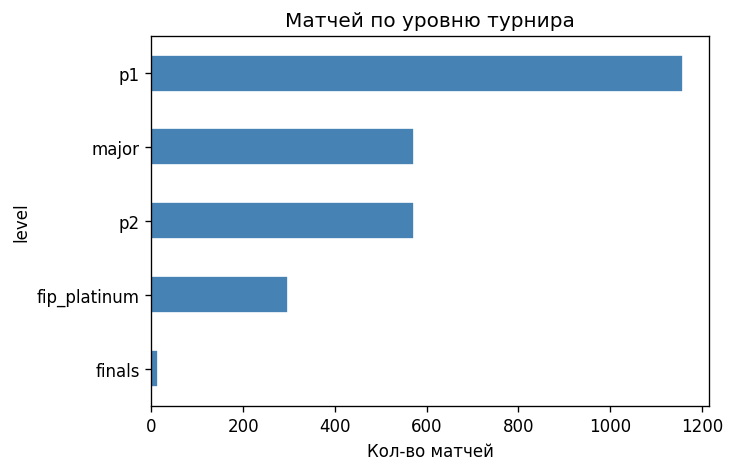

In [93]:
matches_t = matches.merge(tournaments[["tournament_id", "name", "level", "country"]], on="tournament_id", how="left")

print("\nТурниров по годам (по матчам):")
print(matches.groupby("year")["tournament_id"].nunique())
print()
print("Матчей по уровню турнира:")
level_counts = matches_t["level"].value_counts()
print(level_counts)

fig, ax = plt.subplots(figsize=(6, 4))
level_counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Кол-во матчей")
ax.set_title("Матчей по уровню турнира")
ax.invert_yaxis()
plt.show()


### Раунды и статусы


In [63]:
print("Раунды:")
print(matches["round_name"].value_counts())
print()
print("Статусы:")
print(matches["status"].value_counts())


Раунды:
round_name
Round of 32    1003
Round of 64     624
Round of 16     520
Quarter         268
Semifinals      134
Finals           67
Name: count, dtype: int64

Статусы:
status
finished    2549
retired       51
walkover      14
bye            2
Name: count, dtype: int64


### Игроки и пары в матчах


Уникальных игроков в матчах: 405
Игроков в справочнике: 405
Уникальных пар: 768

Медиана матчей на пару: 2
Среднее: 6.8
Макс: 238 (топ-пара)


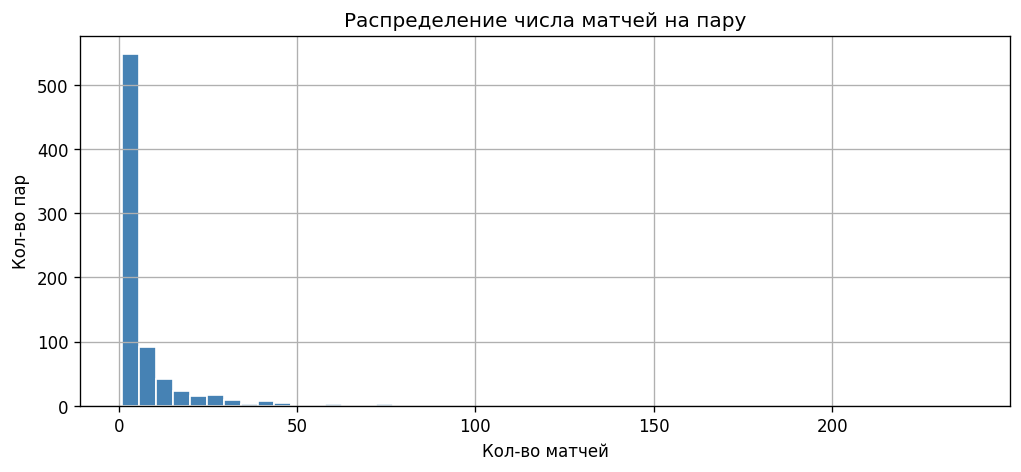

In [64]:
all_player_ids = set(
    matches["player_id_1"].tolist() + matches["player_id_2"].tolist()
    + matches["player_id_3"].tolist() + matches["player_id_4"].tolist()
)
print(f"Уникальных игроков в матчах: {len(all_player_ids)}")
print(f"Игроков в справочнике: {len(players)}")

matches["team_1"] = matches.apply(lambda r: tuple(sorted([r["player_id_1"], r["player_id_2"]])), axis=1)
matches["team_2"] = matches.apply(lambda r: tuple(sorted([r["player_id_3"], r["player_id_4"]])), axis=1)
all_teams = set(matches["team_1"].tolist() + matches["team_2"].tolist())
print(f"Уникальных пар: {len(all_teams)}")
print()

team_match_counts = pd.concat([
    matches["team_1"].value_counts(),
    matches["team_2"].value_counts()
]).groupby(level=0).sum().sort_values(ascending=False)

print(f"Медиана матчей на пару: {team_match_counts.median():.0f}")
print(f"Среднее: {team_match_counts.mean():.1f}")
print(f"Макс: {team_match_counts.max()} (топ-пара)")

fig, ax = plt.subplots(figsize=(10, 4))
team_match_counts.hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Кол-во матчей")
ax.set_ylabel("Кол-во пар")
ax.set_title("Распределение числа матчей на пару")
plt.show()


### Счёт и сетовая структура (`score_json`)


In [115]:
def parse_score(val):
    return int(re.sub(r"\(.*\)", "", val))


def extract_score_info(row):
    if pd.isna(row["score_json"]):
        return pd.Series({"n_sets": None, "set1_winner": None, "has_tiebreak": None})
    sets = json.loads(row["score_json"])
    n_sets = len(sets)

    set1_winner = None
    has_tb = False
    if sets:
        t1, t2 = parse_score(sets[0]["team_1"]), parse_score(sets[0]["team_2"])
        set1_winner = "team_1" if t1 > t2 else "team_2" if t2 > t1 else None
        has_tb = any("(" in s.get("team_1", "") or "(" in s.get("team_2", "") for s in sets)

    return pd.Series({"n_sets": n_sets, "set1_winner": set1_winner, "has_tiebreak": has_tb})


score_info = matches.apply(extract_score_info, axis=1)
matches = pd.concat([matches, score_info], axis=1)

print("Кол-во сетов в матче:")
print(matches["n_sets"].value_counts().sort_index())
print()

valid = matches.dropna(subset=["winner", "set1_winner"])
set1_eq_match = (valid["set1_winner"] == valid["winner"]).mean()
print(f"Победитель 1-го сета = победитель матча: {set1_eq_match:.1%} ({len(valid)} матчей)")

three_set = valid[valid["n_sets"] == 3]
comeback = (three_set["set1_winner"] != three_set["winner"]).mean()
print(f"В 3-сетовых матчах проигравший 1-й сет побеждает: {comeback:.1%} ({len(three_set)} матчей)")
print()

print(f"Матчей с тайбрейком: {matches['has_tiebreak'].sum():.0f} ({matches['has_tiebreak'].mean():.1%})")


Кол-во сетов в матче:
n_sets
1.0      11
2.0    1866
3.0     723
Name: count, dtype: int64

Победитель 1-го сета = победитель матча: 86.0% (2598 матчей)
В 3-сетовых матчах проигравший 1-й сет побеждает: 50.2% (723 матчей)

Матчей с тайбрейком: 612 (23.5%)


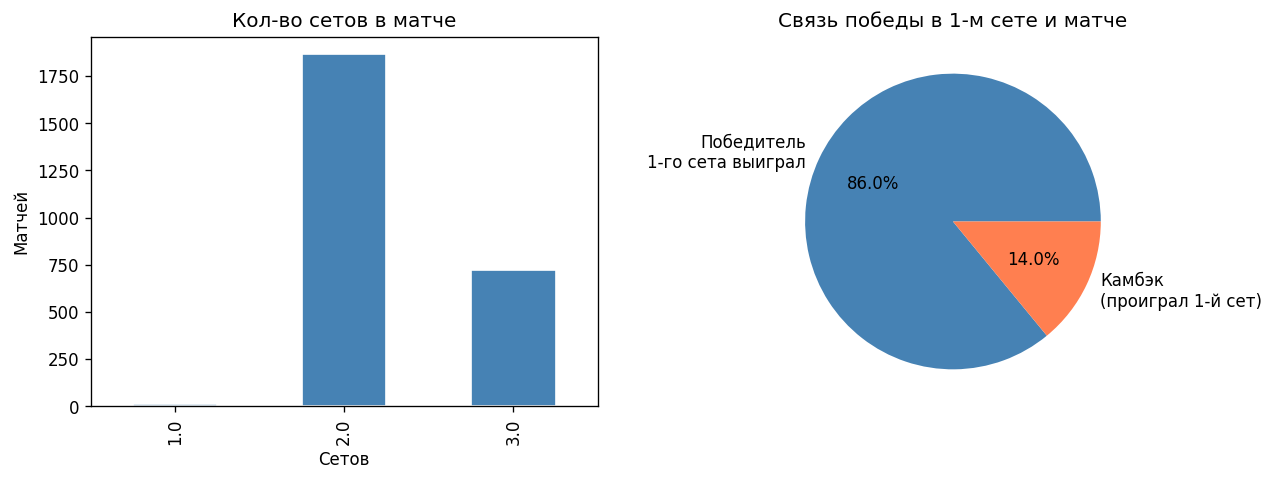

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

matches["n_sets"].value_counts().sort_index().plot.bar(
    ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Кол-во сетов в матче")
axes[0].set_xlabel("Сетов")
axes[0].set_ylabel("Матчей")

labels = ["Победитель\n1-го сета выиграл", "Камбэк\n(проиграл 1-й сет)"]
sizes = [set1_eq_match, 1 - set1_eq_match]
axes[1].pie(sizes, labels=labels, autopct="%1.1f%%", colors=["steelblue", "coral"],
            textprops={"fontsize": 10})
axes[1].set_title("Связь победы в 1-м сете и матче")

plt.show()


### Аномалии счёта по `score_json` (геймы в сете)


In [117]:
def parse_games_no_tb(s1, s2):
    t1, t2 = str(s1), str(s2)
    tb = "(" in t1 or "(" in t2
    g1 = int(re.sub(r"\(.*\)", "", t1))
    g2 = int(re.sub(r"\(.*\)", "", t2))
    return g1, g2, tb


def suspicious_without_tb_paren(g1, g2, tb):
    if tb:
        return False
    hi, lo = max(g1, g2), min(g1, g2)
    if hi <= 6:
        return False
    if hi == 7 and lo in (5, 6):
        return False
    return True


bad_high = []
negative = []
parse_err = 0

for _, row in matches.dropna(subset=["score_json"]).iterrows():
    try:
        sets = json.loads(row["score_json"])
    except (json.JSONDecodeError, TypeError):
        parse_err += 1
        continue
    for si, st in enumerate(sets):
        try:
            g1, g2, tb = parse_games_no_tb(st.get("team_1", ""), st.get("team_2", ""))
        except ValueError:
            parse_err += 1
            continue
        if g1 < 0 or g2 < 0:
            negative.append((row["match_id"], si, st.get("team_1"), st.get("team_2")))
        if suspicious_without_tb_paren(g1, g2, tb):
            bad_high.append((row["match_id"], si, g1, g2, row.get("status")))

print(f"Сетов с подозрительным счётом (нет скобок тайбрейка, не 7-5/7-6): {len(bad_high)}")
if bad_high:
    print("Примеры (match_id, индекс сета, g1, g2, status):", bad_high[:12])
print(f"Сетов с отрицательным числом геймов (после очистки скобок): {len(negative)}")
if negative:
    print("Примеры:", negative[:8])
print(f"Строк score_json с ошибкой парсинга сета: {parse_err}")


Сетов с подозрительным счётом (нет скобок тайбрейка, не 7-5/7-6): 0
Сетов с отрицательным числом геймов (после очистки скобок): 0
Строк score_json с ошибкой парсинга сета: 0


### Point-by-point (`pbp_json`)


In [118]:
def has_real_pbp(val):
    if pd.isna(val):
        return False
    d = json.loads(val)
    return "sets" in d and len(d["sets"]) > 0


matches["has_pbp"] = matches["pbp_json"].apply(has_real_pbp)

print(f"Матчей с PBP (непустые sets): {matches['has_pbp'].sum()} из {len(matches)}")
print()
print("По годам:")
print(matches.groupby("year")["has_pbp"].sum())


Матчей с PBP (непустые sets): 800 из 2616

По годам:
year
2023      0
2024      0
2025    633
2026    167
Name: has_pbp, dtype: int64


### Пропуски `winner` / `score_json`


In [119]:
cols_of_interest = [
    "match_id", "tournament_id", "player_id_1", "player_id_2",
    "player_id_3", "player_id_4", "round_name", "played_at",
    "status", "score_json", "winner", "duration", "stats_json",
]
nulls = matches[cols_of_interest].isnull().sum()
nulls = nulls[nulls > 0]

print("Пропуски")
for col, cnt in nulls.items():
    print(f"  {col}: {cnt} ({cnt / len(matches):.1%})")
print()

no_winner = matches[matches["winner"].isna()]
print(f"Матчи без winner ({len(no_winner)}):")
print(no_winner[["name", "status", "score_json"]])
print()

no_score = matches[matches["score_json"].isna()]
print(f"Матчи без score_json ({len(no_score)}): статусы {no_score['status'].unique().tolist()}")


Пропуски
  score_json: 16 (0.6%)
  winner: 2 (0.1%)
  duration: 1741 (66.6%)

Матчи без winner (2):
                                     name status score_json
1214        Hernandez/Rico - Torre/Valdes    bye        NaN
1612  Munoz/Vilariño - Cardona/Augsburger    bye        NaN

Матчи без score_json (16): статусы ['walkover', 'bye']


### Служебные поля и статусы (аномалии)


In [120]:
print("=== duration ===")
print(f"Всего заполнено: {matches['duration'].notna().sum()} из {len(matches)}")
print()
print("value_counts (топ-10):")
print(matches["duration"].value_counts().head(10))
print()
zero_dur = (matches['duration'] == '00:00').sum()

=== duration ===
Всего заполнено: 875 из 2616

value_counts (топ-10):
duration
01:17    22
01:04    19
01:05    17
01:08    17
01:13    16
01:20    16
01:11    15
01:25    15
01:16    14
01:22    14
Name: count, dtype: int64



Иногда встречается значение `00:00`, колонка заполнена не полностью

In [121]:
print("=== started_time ===")
print(f"Всего заполнено: {matches['started_time'].notna().sum()} из {len(matches)}")
print()
print("value_counts (топ-5):")
print(matches["started_time"].value_counts().head(5))


=== started_time ===
Всего заполнено: 875 из 2616

value_counts (топ-5):
started_time
1970-01-01T01:00:00+01:00    94
2025-04-15T14:08:19+02:00     2
2025-10-06T09:14:21+02:00     2
2025-10-28T18:56:07+01:00     2
2025-06-26T17:08:21+02:00     2
Name: count, dtype: int64


In [122]:
print("=== schedule_label ===")
print(f"Всего заполнено: {matches['schedule_label'].notna().sum()} из {len(matches)}")
print()
print("value_counts (топ-5):")
print(matches["schedule_label"].value_counts().head(5))


=== schedule_label ===
Всего заполнено: 94 из 2616

value_counts (топ-5):
schedule_label
Not before 7:00 PM    13
Not before 4:00 PM    13
Not before 3:00 PM     9
Not before 8:00 PM     8
Not before 6:00 PM     7
Name: count, dtype: int64


In [123]:
print("=== court / court_order ===")
print(f"court заполнен: {matches['court'].notna().sum()} из {len(matches)}")
print(f"court_order заполнен: {matches['court_order'].notna().sum()} из {len(matches)}")
print()
print("court value_counts (топ-5):")
print(matches["court"].value_counts().head(5))


=== court / court_order ===
court заполнен: 414 из 2616
court_order заполнен: 367 из 2616

court value_counts (топ-5):
court
Court 2           49
Center Court      47
Court 1           39
Cancha Estadio    27
Centre Court      24
Name: count, dtype: int64


In [125]:
print("winner по статусам")
print(pd.crosstab(matches["status"], matches["winner"].fillna("NaN")))
print()

print("Матчи с 1 сетом в score")
one_set = matches[matches["n_sets"] == 1]
print(f"Кол-во: {len(one_set)}")
print(f"Статусы: {one_set['status'].value_counts().to_dict()}")
print()

print("Retired-матчи: кол-во сетов")
retired = matches[matches["status"] == "retired"]
print(retired["n_sets"].value_counts().sort_index())


winner по статусам
winner    NaN  team_1  team_2
status                       
bye         2       0       0
finished    0    1269    1280
retired     0      23      28
walkover    0       6       8

Матчи с 1 сетом в score
Кол-во: 11
Статусы: {'retired': 11}

Retired-матчи: кол-во сетов
n_sets
1.0    11
2.0    27
3.0    13
Name: count, dtype: int64


**Дальше:** `02_data_preprocessing.ipynb`, обработка колонок, очистка от лишних
